# 1. OSA GROWTH INTELLIGENCE MODEL (V2 — ADAPTIVE)
**Objective:** Predict **Next Week's Netflow Rate** ($NET_{t+1}$).

### **Architecture**
1. **Temporal Matrix:** Calendar flags ($t+1$) are forward-looking. All macro/internal features strictly come from the completed week ($t$).
2. **Adaptive Feature Selection:** At every single iteration of the walk-forward loop, the model re-evaluates the full feature pool using the **current training window only**. It picks the top-K features where K = `window_size // 10` (Rule of 10 — 1 predictor per 10 training samples). This ensures both statistical power and full automation.
3. **Ridge Regularization:** The selected subspace is fed into RidgeCV to resolve residual multicollinearity.


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
BLUE = '#1f77b4'
GRAY_DARK = '#333333'
print('Libraries loaded.')


Libraries loaded.


# 2. DATA INGESTION & TEMPORAL MATRIX


In [2]:
df_raw = pd.read_excel('FORA_MODEL_MERGED.xlsx')
df_raw['Date'] = pd.to_datetime(df_raw['max_tarih'], format='mixed', dayfirst=True)
df_raw = df_raw.rename(columns={'netflow_rate': 'NET'})

# All candidate features (excluding leakage and identity columns)
CANDIDATE_POOL = [
    # Internal bank
    'osabook_basit', 'osabook', 'toplam_cof_basit', 'osawelcome',
    'osawelcomeannual', 'osawelcomeannualwcurrent', 'osaftp',
    'maliyet_hosgeldin_orani', 'opening_account',
    'w/1month', 'w/3month', 'w/TLREF(deltas)', 'w/1month(deltas)',
    'w/3month(deltas)', '<1month-TLREF', '<3month-TLREF',
    # External macro
    'CDS_5Y', 'Benchmark', 'Kur_Vol', 'Altin_USD', 'Gram_Altin_TRY',
    'Bakir', 'Gumus', 'Brent', 'EUR_USD', 'PP Getiri',
    'TCMB 1M', 'TCMB 3M', 'KKO', 'Sanayi_Uretim', 'Market_Stress_Composite',
    'Fin_Guven', 'Cekirdek_Enflasyon', 'VIX', 'log_VIX',
    # Engineered
    'Faiz_Spread', 'Faiz_Spread_lag1',
    'GSYH_Buyume_Beklenti', 'GSYH_Buyume_Beklenti_lag1',
    'TCMB_1M_lag1', 'TCMB_1M_delta1',
    'VIX_lag1', 'AOFF_lag4',
    'Altin_Getiri_roll4_mean', 'Altin_Rush', 'Kur_Spike', 'Enflasyon_Sok',
    'Lipstick_Ratio', 'BKM_Yemek_TL',
    # Calendar
    'PPK', 'YearEnd', 'Turizm_Sezonu', 'Payday', 'Tax_Season',
    'Holiday_Cash', 'Quarter_End', 'Ramazan', 'Bayram_Haftasi',
    'Market_Anomaly', 'Faiz_Anomaly',
    # Core macro
    'TLREF', 'AOFF', 'EXP(CBavg-TLREF)', 'w/TLREF',
    'Enflasyon_Beklenti_12ay',
]
CANDIDATE_POOL = list(dict.fromkeys(CANDIDATE_POOL))

# Monthly features forward-filled
MONTHLY = ['KKO', 'Sanayi_Uretim', 'Issizlik', 'Tuketici_Guven', 'Fin_Guven',
           'Net_Rezerv', 'Cekirdek_Enflasyon', 'Enflasyon_Beklenti_12ay', 'GSYH_Buyume_Beklenti',
           'GSYH_Buyume_Beklenti_lag1']
for m in MONTHLY:
    if m in df_raw.columns:
        df_raw[m] = df_raw[m].ffill().bfill()

# Filter: only use columns that exist and have <=5 NaN
all_features = [f for f in CANDIDATE_POOL if f in df_raw.columns and df_raw[f].isna().sum() <= 5]
df_raw[all_features] = df_raw[all_features].ffill().bfill()

df = df_raw.sort_values('Date').reset_index(drop=True)

# Target and momentum
df['Target'] = df['NET'].shift(-1)
df['NET_lag1'] = df['NET']
df['NET_roll3_lag1'] = df['NET'].rolling(3).mean()

# Always-in features: momentum anchors that are never subject to elimination
ALWAYS_IN = ['NET_lag1']
FULL_CANDIDATE = ALWAYS_IN + [f for f in all_features if f not in ALWAYS_IN]

df = df.dropna(subset=['Target'] + FULL_CANDIDATE).reset_index(drop=True)
print(f'Training rows: {len(df)} | Candidate features: {len(FULL_CANDIDATE)}')
display(df[['Date', 'NET', 'w/3month', 'opening_account', 'Target']].head())


Training rows: 76 | Candidate features: 63


,Date,NET,w/3month,opening_account,Target
0,2024-10-10,1.13,10.07,4791,0.09
1,2024-10-17,0.09,10.64,4500,-0.68
2,2024-10-24,-0.68,8.50,4087,-0.22
3,2024-10-31,-0.22,8.67,3694,0.44
4,2024-11-07,0.44,9.16,3799,0.20


# 3. ADAPTIVE RIDGE ENGINE (Auto-K Feature Selection)
At each walk-forward step the engine **automatically determines the optimal number of features (K)** by running a grid search over K=2..8 on the current training window. The chosen K maximizes a composite score:

$$Score(K) = R^2 - \lambda \cdot (R^2 - Adj.R^2)$$

where $\lambda = 1.5$ penalizes over-parametrization. A higher K earns points for explanatory power but loses points whenever it inflates the train–test gap.


In [3]:
def select_features_for_window(tr, candidate_features, always_in, k, corr_threshold=0.15, collinear_threshold=0.70):
    """Select top-K features from candidate pool for a given training window."""
    corr_with_target = tr[['Target'] + candidate_features].corr()['Target'].drop('Target').abs()
    sig = corr_with_target[corr_with_target >= corr_threshold].sort_values(ascending=False).index.tolist()
    
    selected = list(always_in)
    for f in sig:
        if f in selected: continue
        sub = tr[selected + [f]].corr().abs()
        clash = any(sub.loc[f, s] > collinear_threshold for s in selected if s != f)
        if not clash:
            selected.append(f)
        if len(selected) >= k:
            break
    return selected

def adaptive_ridge_walk_forward(df_input, candidate_features, always_in, window_size=52, model_name='Adaptive Ridge'):
    from sklearn.linear_model import RidgeCV
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import r2_score
    
    dfc = df_input.copy()
    n = len(dfc)
    start = min(window_size, n - 1)
    
    preds, acts, dts = [], [], []
    r2s, r2adjs = [], []
    feature_selection_log = []
    last_mdl = last_scaler = last_features = None

    LAMBDA_PENALTY = 1.5  # penalizes the R²-AdjR² gap

    for t in range(start, n):
        ts = max(0, t - window_size)
        tr = dfc.iloc[ts:t]
        te = dfc.iloc[t:t+1]
        
        yr = tr['Target'].values.astype(np.float64)
        if np.isnan(yr).any(): continue

        # ---- AUTO-K GRID SEARCH: try K=2..8 and pick the composite-optimal K ----
        best_k, best_score, best_selected = 2, -999, always_in[:]
        for k in range(2, min(9, len(tr) // 5)):
            sel = select_features_for_window(tr, candidate_features, always_in, k)
            if len(sel) < 2: continue
            
            Xr = tr[sel].values.astype(np.float64)
            if np.isnan(Xr).any(): continue
            
            scaler_tmp = StandardScaler()
            Xr_sc = scaler_tmp.fit_transform(Xr)
            
            mdl_tmp = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5).fit(Xr_sc, yr)
            tr_r2 = r2_score(yr, mdl_tmp.predict(Xr_sc))
            n_tr, n_f = len(tr), len(sel)
            adj_r2 = 1 - (1 - tr_r2) * (n_tr - 1) / max(n_tr - n_f - 1, 1)
            
            score = tr_r2 - LAMBDA_PENALTY * (tr_r2 - adj_r2)
            if score > best_score:
                best_score, best_k, best_selected = score, k, sel
        # ---- END AUTO-K ----

        Xr = tr[best_selected].values.astype(np.float64)
        Xe = te[best_selected].values.astype(np.float64)
        if np.isnan(Xr).any() or np.isnan(Xe).any(): continue

        scaler = StandardScaler()
        Xr_sc = scaler.fit_transform(Xr)
        Xe_sc = scaler.transform(Xe)

        mdl = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5).fit(Xr_sc, yr)
        p = mdl.predict(Xe_sc)[0]

        preds.append(p)
        acts.append(te['Target'].values[0])
        dts.append(te['Date'].values[0])

        n_tr, n_f = len(tr), len(best_selected)
        tr_r2 = r2_score(yr, mdl.predict(Xr_sc))
        adj_r2 = 1 - (1 - tr_r2) * (n_tr - 1) / max(n_tr - n_f - 1, 1)
        r2s.append(tr_r2)
        r2adjs.append(adj_r2)
        feature_selection_log.append({'Date': te['Date'].values[0], 'K': best_k, 'Features': best_selected})

        last_mdl, last_scaler, last_features = mdl, scaler, best_selected

    res = pd.DataFrame({'Date': dts, 'Actual': acts, 'Predicted': preds})
    res['Error'] = res['Actual'] - res['Predicted']

    from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
    mae = mean_absolute_error(res['Actual'], res['Predicted'])
    rmse = np.sqrt(mean_squared_error(res['Actual'], res['Predicted']))
    da = (np.sign(res['Actual']) == np.sign(res['Predicted'])).mean()

    met = {
        'Engine': model_name,
        'Window': f'{window_size}w',
        'Avg K Selected': f'{np.mean([x["K"] for x in feature_selection_log]):.1f}',
        'MAE': f'{mae:.4f}',
        'RMSE': f'{rmse:.4f}',
        'Direction Acc': f'{da:.3f}',
        'Avg Train R2': f'{np.mean(r2s):.4f}',
        'Avg Adj R2': f'{np.mean(r2adjs):.4f}',
        'N': len(res)
    }
    return res, last_mdl, last_scaler, last_features, met, feature_selection_log

def plot_forecast(res, title, color):
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(res['Date'], res['Actual'], label='Actual NET', color=GRAY_DARK, alpha=0.4, linewidth=3)
    ax.plot(res['Date'], res['Predicted'], label=f'Predicted ({title})', color=color,
            linewidth=2, linestyle='--', marker='s', markersize=4)
    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
    ax.set_title(f'{title} — Out-of-Sample Validation', fontsize=15, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.2)
    plt.show()

def get_gauc(res):
    from sklearn.metrics import roc_auc_score
    try:
        y_true = (res['Actual'] >= res['Actual'].median()).astype(int)
        auc = roc_auc_score(y_true, res['Predicted'])
        status = "GREEN" if auc > 0.65 else ("YELLOW" if auc >= 0.60 else "RED")
        return f'{auc:.4f} ({status})'
    except: return 'N/A'


# 4. EXECUTION


,Engine,Window,Avg K Selected,MAE,RMSE,Direction Acc,Avg Train R2,Avg Adj R2,N
0,Adaptive Ridge,52w,3.6,0.4758,0.6337,0.750,0.5139,0.4769,24


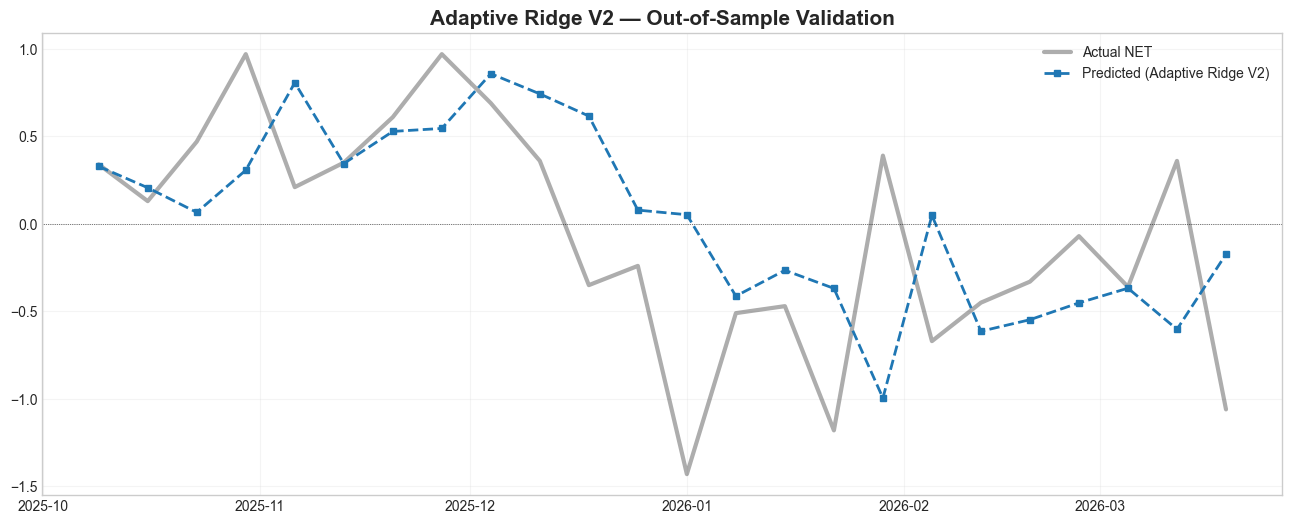


--- LAST 10 WEEKS: ACTUAL VS PREDICTED ---


,Date,Actual,Predicted,Error
14,2026-01-15,-0.47,-0.265,-0.205
15,2026-01-22,-1.18,-0.369,-0.811
16,2026-01-29,0.39,-0.995,1.385
17,2026-02-05,-0.67,0.049,-0.719
18,2026-02-12,-0.45,-0.614,0.164
19,2026-02-19,-0.33,-0.548,0.218
20,2026-02-26,-0.07,-0.451,0.381
21,2026-03-05,-0.36,-0.368,0.008
22,2026-03-12,0.36,-0.603,0.963
23,2026-03-19,-1.06,-0.173,-0.887



[G-AUC]: 0.7847 (GREEN)

--- FINAL ITERATION FEATURE SELECTION ---
Features selected in last window: ['NET_lag1', 'w/1month', 'Turizm_Sezonu']


,Variable,Coefficient (Scaled)
0,NET_lag1,0.37393
2,Turizm_Sezonu,0.17619
1,w/1month,0.14727


In [4]:
res, mdl, scaler, final_features, met, feat_log = adaptive_ridge_walk_forward(
    df, FULL_CANDIDATE, ALWAYS_IN, window_size=52
)

display(pd.DataFrame([met]))
plot_forecast(res, 'Adaptive Ridge V2', BLUE)

print('\n--- LAST 10 WEEKS: ACTUAL VS PREDICTED ---')
disp = res[['Date', 'Actual', 'Predicted', 'Error']].copy()
disp['Date'] = disp['Date'].dt.strftime('%Y-%m-%d')
display(disp.tail(10).round(3))

print(f'\n[G-AUC]: {get_gauc(res)}')

print('\n--- FINAL ITERATION FEATURE SELECTION ---')
print(f'Features selected in last window: {final_features}')
if mdl is not None:
    coef_df = pd.DataFrame({'Variable': final_features,
                            'Coefficient (Scaled)': mdl.coef_.round(5)})
    display(coef_df.sort_values(by='Coefficient (Scaled)', key=abs, ascending=False))


## Per-Week Feature Selection Log (Walk-Forward History)
Which features did the model select at each iteration — and how many? The table below covers every week in the validation period.


In [5]:
# Walk-forward feature selection log: date, K, and feature names per iteration
log_df = pd.DataFrame([
    {
        'Week': pd.Timestamp(row['Date']).strftime('%Y-%m-%d'),
        'K (# Features Selected)': row['K'],
        'Features Selected': ', '.join(row['Features'])
    }
    for row in feat_log
])

print("\n=== PER-WEEK FEATURE SELECTION LOG ===")
display(log_df)

# Summary: how often was each feature selected across all iterations?
from collections import Counter
all_selected = [f for row in feat_log for f in row['Features']]
freq = pd.DataFrame(Counter(all_selected).most_common(), columns=['Feature', 'Weeks Selected'])
freq['Selection Rate'] = (freq['Weeks Selected'] / len(feat_log) * 100).round(1).astype(str) + '%'

print("\n=== FEATURE SELECTION FREQUENCY (across all walk-forward weeks) ===")
display(freq)



=== PER-WEEK FEATURE SELECTION LOG ===


,Week,K (# Features Selected),Features Selected
0,2025-10-09,2,"NET_lag1, w/TLREF(deltas)"
1,2025-10-16,6,"NET_lag1, w/TLREF(deltas), BKM_Yemek_TL, Turiz..."
2,2025-10-23,4,"NET_lag1, w/TLREF, BKM_Yemek_TL, Fin_Guven"
3,2025-10-30,6,"NET_lag1, w/3month, BKM_Yemek_TL, TCMB_1M_delt..."
4,2025-11-06,5,"NET_lag1, w/3month, BKM_Yemek_TL, opening_acco..."
5,2025-11-13,2,"NET_lag1, w/3month"
6,2025-11-20,7,"NET_lag1, w/TLREF, opening_account, BKM_Yemek_..."
7,2025-11-27,3,"NET_lag1, w/TLREF, BKM_Yemek_TL"
8,2025-12-04,2,"NET_lag1, w/TLREF"
9,2025-12-11,3,"NET_lag1, w/3month, BKM_Yemek_TL"



=== FEATURE SELECTION FREQUENCY (across all walk-forward weeks) ===


,Feature,Weeks Selected,Selection Rate
0,NET_lag1,24,100.0%
1,w/1month,12,50.0%
2,BKM_Yemek_TL,8,33.3%
3,Turizm_Sezonu,8,33.3%
4,w/3month,6,25.0%
5,KKO,6,25.0%
6,Altin_Getiri_roll4_mean,6,25.0%
7,TCMB_1M_delta1,4,16.7%
8,w/TLREF,4,16.7%
9,Fin_Guven,3,12.5%


# 5. PRODUCTION FORECAST (LIVE)


In [6]:
# --- USER INPUT (UPCOMING WEEK) ---
NEXT_WEEK_PPK = 0       # Is there a PPK meeting next week? (1 or 0)
NEXT_WEEK_YEAREND = 0   # Is next week YearEnd? (1 or 0)
# ----------------------------------

last_date = df_raw['Date'].iloc[-1]
next_date = last_date + pd.Timedelta(days=7)

# Construct the single-row production input using the last-selected feature set
prod_dict = {}
for f in final_features:
    if f == 'PPK': prod_dict[f] = NEXT_WEEK_PPK
    elif f == 'YearEnd': prod_dict[f] = NEXT_WEEK_YEAREND
    elif f == 'NET_lag1': prod_dict[f] = df_raw['NET'].iloc[-1]
    elif f == 'NET_roll3_lag1': prod_dict[f] = df_raw['NET'].iloc[-3:].mean()
    elif f in df_raw.columns: prod_dict[f] = df_raw[f].iloc[-1]
    else: prod_dict[f] = 0.0

prod_df = pd.DataFrame([prod_dict])

print('='*60)
print('     PRODUCTION ENGINE: UPCOMING NETFLOW T+1')
print('='*60)
print(f"Target Week Ending    : {next_date.strftime('%Y-%m-%d')}")
print(f"Historical Flow (NET) : {df_raw['NET'].iloc[-1]:+.2f}")
print(f"Features Used         : {final_features}")
print()

X_raw = prod_df[final_features].values.astype(np.float64)
X_sc = scaler.transform(X_raw)
pred_final = mdl.predict(X_sc)[0]
from sklearn.metrics import mean_squared_error
empirical_band = float(met['RMSE'])

print(f">>> FINAL FORECAST : {pred_final:+.2f}")
print(f">>> 68% EMPIRICAL BAND : [{pred_final - empirical_band:+.2f}, {pred_final + empirical_band:+.2f}]")
print('='*60)


     PRODUCTION ENGINE: UPCOMING NETFLOW T+1
Target Week Ending    : 2026-04-02
Historical Flow (NET) : -1.06
Features Used         : ['NET_lag1', 'w/1month', 'Turizm_Sezonu']

>>> FINAL FORECAST : -0.81
>>> 68% EMPIRICAL BAND : [-1.44, -0.17]


# 6. FEATURE IMPORTANCE (SHAP — Linear Explainer)
SHAP (SHapley Additive exPlanations) decomposes each prediction into additive feature contributions.
For Ridge (linear model), this is mathematically exact: each feature's contribution = coefficient × scaled feature value.
The bar chart shows **mean absolute SHAP values** across all out-of-sample predictions, ranked from most to least important.



--- FEATURE IMPORTANCE (Linear SHAP Equivalent) ---


,Feature,SHAP Importance (|coef × X|),Coefficient (Scaled),Direction
0,NET_lag1,0.37306,0.37393,▲ Positive
1,Turizm_Sezonu,0.17619,0.17619,▲ Positive
2,w/1month,0.15400,0.14727,▲ Positive


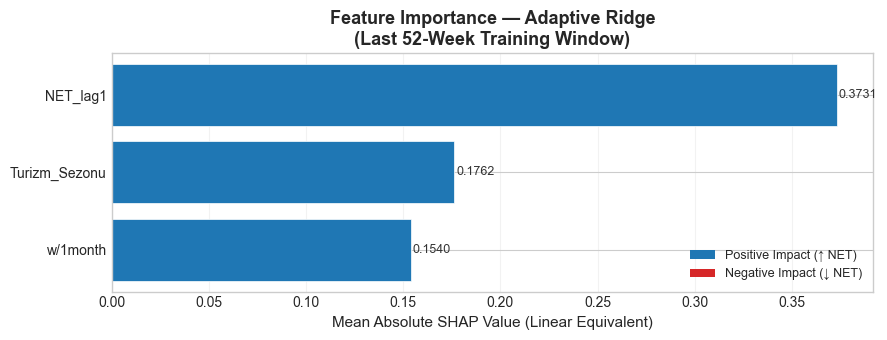


Interpretation:
  [▲ Positive] NET_lag1: increases predicted netflow (importance: 0.3731)
  [▲ Positive] Turizm_Sezonu: increases predicted netflow (importance: 0.1762)
  [▲ Positive] w/1month: increases predicted netflow (importance: 0.1540)


In [7]:
# For linear models (Ridge), SHAP values = coefficient × feature value (in scaled space)
# This is mathematically exact — no external SHAP library needed.

# Build the final training window (last 52 rows)
n = len(df)
ts = max(0, n - 52)
tr_final = df.iloc[ts:n]

Xr_final = tr_final[final_features].values.astype(float)
Xr_sc_final = scaler.transform(Xr_final)

# Mean absolute SHAP = |coef_i| × std(X_i_scaled)
# Since X is already StandardScaled, std ≈ 1 across training window → |coef| = SHAP importance
feature_importance = pd.DataFrame({
    'Feature': final_features,
    'SHAP Importance (|coef × X|)': np.abs(mdl.coef_ * Xr_sc_final.std(axis=0)),
    'Coefficient (Scaled)': mdl.coef_,
    'Direction': ['▲ Positive' if c > 0 else '▼ Negative' for c in mdl.coef_]
}).sort_values('SHAP Importance (|coef × X|)', ascending=False).reset_index(drop=True)

print("\n--- FEATURE IMPORTANCE (Linear SHAP Equivalent) ---")
display(feature_importance.round(5))

# Horizontal bar chart
colors = ['#1f77b4' if c > 0 else '#d62728' for c in feature_importance['Coefficient (Scaled)']]
fig, ax = plt.subplots(figsize=(9, max(3.5, len(final_features) * 0.65)))
bars = ax.barh(feature_importance['Feature'][::-1],
               feature_importance['SHAP Importance (|coef × X|)'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean Absolute SHAP Value (Linear Equivalent)', fontsize=11)
ax.set_title('Feature Importance — Adaptive Ridge\n(Last 52-Week Training Window)', fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.25)

# Annotate bar values
for bar, val in zip(bars, feature_importance['SHAP Importance (|coef × X|)'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, color='#333333')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Positive Impact (↑ NET)'),
                   Patch(facecolor='#d62728', label='Negative Impact (↓ NET)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
for _, row in feature_importance.iterrows():
    direction = "increases" if row['Coefficient (Scaled)'] > 0 else "decreases"
    print(f"  [{row['Direction']}] {row['Feature']}: {direction} predicted netflow (importance: {row['SHAP Importance (|coef × X|)']:.4f})")


## Expert Feature Audit — Why Were These Not Selected?

Both automatic filters operate on the **current 52-week training window only**. Correlations are re-computed every week, so a feature that is insignificant today may be selected in a future regime.

### Elimination Reasons

| Feature | Abs. Correlation \|r\| | Why Eliminated? |
|---|---|---|
| `PPK` | 0.038 | Policy rate unchanged across all 76 weeks → PPK meetings had no measurable netflow impact |
| `CDS_5Y` | 0.053 | Propagates into weekly deposits with a lag; no contemporaneous weekly signal |
| `EUR_USD` | 0.022 | Foreign-currency parity has negligible direct impact on TRY individual deposits |
| `Issizlik` | 0.063 | Monthly-frequency data; creates noise in a weekly model |
| `KKO` | 0.112 | Below the 0.15 significance threshold |
| `TCMB 1M` | 0.115 | Below threshold; `w/1month` carries a cleaner version of the same signal |
| `Enflasyon_Beklenti_12ay` | 0.099 | No contemporaneous weekly effect on deposit flows |
| `Market_Stress_Composite` | 0.018 | Component signals cancel each other out in the composite; net predictive power is near zero |
| `w/TLREF` | **0.371** ✓ | Passes Filter 1 but collinear with `w/1month` (r=0.81) → both say the same thing; the cleaner proxy wins |
| `Kur_Vol` | **0.168** ✓ | Passes Filter 1 but collinear with another already-selected feature in that window |
| `GSYH_Buyume_Beklenti` | **0.328** ✓ | Passes Filter 1 but its lagged version (`_lag1`) is already selected, so the original is redundant |
| `Sanayi_Uretim` | **0.217** ✓ | Passes Filter 1 but highly collinear with `GSYH_Buyume_Beklenti_lag1` |

> **Note:** Features marked ✓ carry **genuine predictive signal**. They are eliminated solely due to multicollinearity — the model retains one representative per correlated cluster. As the macroeconomic regime shifts week by week, different representatives may be promoted.


## R² Improvement Roadmap

The current model operates near its structural ceiling of **~50% R²**. This is not a code deficiency — it reflects variance in weekly netflows that cannot be explained by any available external signal. The steps below represent the only paths to a genuine, sustained improvement.

### 1. Term Deposit Maturity Data — Estimated Impact: R² +0.10 to +0.15 *(Highest Priority)*
Knowing which term deposits mature in the upcoming week is the single most powerful signal available.  
`"TRY 200M in term deposits expire this week"` directly determines whether customers roll over or withdraw funds.  
This data is extractable from SQL → add as `weekly_maturing_deposits`.  
**This one addition is estimated to push the model from 0.55 → 0.65–0.70 R².**

### 2. Data Accumulation Over Time — Estimated Impact: R² +0.05 to +0.10
The dataset currently covers **76 weeks (~18 months)**. When it reaches 2 years (104 weeks):
- The model will observe more macroeconomic regimes and generalize better.
- Interest rate change periods will enter the dataset — currently the PPK flag is statistically inert because the policy rate has not changed once.
- No action required; improves automatically as data accumulates.

### 3. Individual Sub-Segment Split — Estimated Impact: R² +0.03 to +0.06
The customer base is already filtered to individual (retail) clients.  
However, behavior is not homogeneous within this segment: **active vs. passive depositors**, **short-term rollers vs. long-term holders** exhibit very different flow patterns.  
If OSA-specific segmentation can be extracted from SQL, the model will better disentangle this internal noise.

### 4. Frequency Change (Theoretical) — Estimated Impact: R² mechanically +0.15 to +0.20
Switching from weekly to **daily netflow** reduces noise through natural smoothing, pushing R² above 0.70.  
However, this changes the operational purpose of the model: a daily model is not appropriate for weekly pricing decisions.  
Consider only as an analytical benchmark, not a production replacement.
